# **02. PreProcessing & Feature Enginerring**

In [64]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')



In [65]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [66]:
# Read cleaned dataset from previous notebook

clean_files = []
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "processed")
for file in data_path.rglob("*.csv"):
    clean_files.append(file)
    print(file.name)
    print(clean_files.index(file), " ", file)

test_cleaned.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\test_cleaned.csv
train_cleaned.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\train_cleaned.csv


In [67]:
print("Loading Cleaned data....")
train_cleaned = pd.read_csv(clean_files[1])
test_cleaned = pd.read_csv(clean_files[0])


Loading Cleaned data....


In [68]:
# Data type in train and test datasets should be same for all columns. Let's check that.
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())

object     43
int64      35
float64     3
Name: count, dtype: int64
object     43
int64      26
float64    11
Name: count, dtype: int64


In [69]:
train_cleaned['GarageYrBlt'] = train_cleaned['GarageYrBlt'].astype('int64')
test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']] = test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']].astype('int64')

In [70]:
# check data types of train and test datasets after conversion
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())

object     43
int64      36
float64     2
Name: count, dtype: int64
object     43
int64      35
float64     2
Name: count, dtype: int64


In [71]:
train_data = train_cleaned.copy()
test_data = test_cleaned.copy()

# Keeping those datapoints where yrsold is greater than or equal to year remodeled
train_data = train_data[train_data['YrSold'] >= train_data['YearRemodAdd']]
test_data = test_data[test_data['YrSold'] >= test_data['YearRemodAdd']]
test_id = test_data['Id']

#### **1. Feature Engineering**

**1.1. For Continuous & Seasonal Features**

In [72]:
def feature_engineering(df):

    result = df.copy()

    """
    Create new features : In this step I will create new features from weaker features in the training data. 
    For example, the surface area of each floor has low correlation with house price; 
    however, when we sum them up, the relationship becomes much stronger. 
    In fact, TotalSqFeet becomes the strongest feature in the dataset. 
    The new features I will create are total square feet, total number of bathrooms, age of the house, 
    whether the house was remodeled, and whether the house was sold in the same year it was built.
    """
    # Create new feature 'TotalSF' as the sum of 'TotalBsmtSF', '1stFlrSF', and '2ndFlrSF' 
    result['TotalSF'] = result['TotalBsmtSF'] + result['1stFlrSF'] + result['2ndFlrSF']
    
    # Create new feature 'TotalBath' as the sum of all bathroom-related features
    result['TotalBath'] = (result['FullBath'] + 0.5 * result['HalfBath'] + 
                       result['BsmtFullBath'] + 0.5 * result['BsmtHalfBath'])
    
    # Create new feature 'TotalPorchSF' as the sum of all porch-related features
    result['TotalPorchSF'] = (result['OpenPorchSF'] + result['EnclosedPorch'] + 
                          result['3SsnPorch'] + result['ScreenPorch'] + result['WoodDeckSF'])
    
    # Create new feature 'HouseAge' as the difference between the year sold and the year built
    result['HouseAge'] = result['YrSold'] - result['YearBuilt']

    # Create new feature 'Remodeled' to indicate whether the house was remodeled and remodeled age
    result['Remodeled'] = (result['YearRemodAdd'] != result['YearBuilt']).astype('bool')
    result['RemodeledAge'] = result['YrSold'] - result['YearRemodAdd']

    # Create new feature 'SameYearSale' to indicate whether the house was sold in the same year it was built
    result['SameYearSale'] = (result['YrSold'] == result['YearBuilt']).astype('bool')

    # Create new feature 'BathToBedRatio' as the ratio of total bathrooms to total bedrooms
    result['BathToBedRatio'] = result['TotalBath'] / (result['BedroomAbvGr'] + 1)  # Adding 1 to avoid division by zero

    # Has Amenities flags
    result['HasFireplace'] = (result['Fireplaces'] > 0).astype('bool')
    result['HasGarage'] = (result['GarageCars'] > 0).astype('bool')
    result['HasBasement'] = (result['TotalBsmtSF'] > 0).astype('bool')
    result['HasPorch'] = (result['OpenPorchSF'] > 0).astype('bool')


    # Non-linear relationships
    result['OverallQualSquared'] = result['OverallQual'] ** 2

    # Feature Interactions
    result['LivAreaQual'] = result['GrLivArea'] * result['OverallQual']
    result['QualCond'] = result['OverallQual'] * result['OverallCond']

    return result



# Applying feature engineering to both train and test datasets
print("="*20, "Applying feature engineering to datasets...", "="*20)
train_processed = feature_engineering(train_data)
test_processed = feature_engineering(test_data)

==================== Applying feature engineering to datasets... ====================


In [73]:
# Compute neighborhood-wise median sale price and create a new feature 'NeighborhoodMedianPrice' (only using training dataset)
neighborhood_price = train_processed.groupby('Neighborhood')['SalePrice'].median()
train_processed['NeighborhoodMedianPrice'] = train_processed['Neighborhood'].map(neighborhood_price)

# For test data, map the same neighborhood values from training data
test_processed['NeighborhoodMedianPrice'] = test_processed['Neighborhood'].map(neighborhood_price)

In [74]:
print(train_processed.dtypes.value_counts())
print(test_processed.dtypes.value_counts())

int64      43
object     43
bool        6
float64     5
Name: count, dtype: int64
object     43
int64      42
bool        6
float64     5
Name: count, dtype: int64


In [75]:
# Copying features for furthur use
train_df = train_processed.copy()
test_df = test_processed.copy()

In [76]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,HouseAge,Remodeled,RemodeledAge,SameYearSale,BathToBedRatio,HasFireplace,HasGarage,HasBasement,HasPorch,OverallQualSquared,LivAreaQual,QualCond,NeighborhoodMedianPrice
0,1,60,RL,65.0,8450,Pave,No,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,2,2008,WD,Normal,208500,2566,3.5,61,5,False,5,False,0.875,False,True,True,True,49,11970,35,197200.0
1,2,20,RL,80.0,9600,Pave,No,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,No,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No,No,No,0,5,2007,WD,Normal,181500,2524,2.5,298,31,False,31,False,0.625,True,True,True,False,36,7572,48,218000.0
2,3,60,RL,68.0,11250,Pave,No,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No,No,No,0,9,2008,WD,Normal,223500,2706,3.5,42,7,True,6,False,0.875,True,True,True,True,49,12502,35,197200.0
3,4,70,RL,60.0,9550,Pave,No,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,No,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No,No,No,0,2,2006,WD,Abnorml,140000,2473,2.0,307,91,True,36,False,0.500,True,True,True,True,49,12019,35,200624.0
4,5,60,RL,84.0,14260,Pave,No,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No,No,No,0,12,2008,WD,Normal,250000,3343,3.5,276,8,False,8,False,0.700,True,True,True,True,64,17584,40,301500.0


## **2. Features Selection**

This feature set was chosen to keep the model both effective and straightforward.

__1. Missing Values Features__ with more than 6% missing values

__2. Correlation with price__ ensures we use features most strongly tied to home values.

__3. Low multicollinearity__ means each feature adds unique information.

__4. Domain knowledge__ highlights what experts know drives property value.

__5. Transformed relationships__ capture non-linear effects more clearly.

__6. Dimensionality reduction__ keeps the model simpler without losing power.

Together, these features give a clear, balanced view of the most important factors that determine home prices in Ames.

**2.1. Top n-Numeric Features**


In [77]:
numeric_columns = train_df.select_dtypes(include='number').columns.tolist()

**2.1.1. Drop Missing Values**


In [78]:
# Dropping features with more tham 6% missing
to_drop = ['LotFrontage']
numeric_col = [col for col in numeric_columns if col not in to_drop]


**2.1.2. Feature Selection f_regression vs r_regression**

Both f_regression and r_regression are used to select feature selection based on linear relationship between the feature and the target variable.

- **f_regression** is preferred because it provides F-scores and p-values to access feature importance,independent
of positive and negative associations.

- **r_regression** computes Pearson correlation coefficient, returns values between -1 and 1, but lacks p-values and F-scores, making it less useful for assessing statistical significance.

For most models, **f_regression** is  prefered because of its statistically reliable nature.


In [79]:
numeric_col = [col for col in numeric_col if col not in ['Id', 'SalePrice']]

from sklearn.feature_selection import f_regression

def compute_f_scores_with_eta(X, y):
    """
    Compute f_regression scores, p-values, and eta squared for numeric features.
    
    Parameters:
    X (pd.DataFrame): Feature matrix
    y (pd.Series): Target variable
    top_n (int): Number of top features to return (default=35)
    
    Returns:
    pd.DataFrame: Features with F-scores, p-values, and eta squared
    """
    # Select numeric features only
    X_num = X.select_dtypes(include='number')
    
    # Compute F-scores and p-values
    f_score, p_value = f_regression(X_num, y)
    
    # Compute eta squared
    n_samples = len(y)
    eta_sq = f_score / (f_score + (n_samples - 2))
    
    # Build results DataFrame
    scores_df = pd.DataFrame({
        'Feature': X_num.columns,
        'F-Score': np.round(f_score, 4),
        'P-Value': np.round(p_value, 6),
        'Eta_Squared': eta_sq
    }).sort_values(by=['F-Score'], ascending=False).reset_index(drop=True)
    
    return scores_df

# Apply F-Test for numeric features
scores_df = compute_f_scores_with_eta(train_df[numeric_col], train_df['SalePrice'])
display(scores_df.sort_values(by='Eta_Squared', ascending=False, ignore_index=True))


,Feature,F-Score,P-Value,Eta_Squared
0,LivAreaQual,3692.7115,0.000000,0.717072
1,OverallQualSquared,3000.9267,0.000000,0.673166
2,TotalSF,2472.3108,0.000000,0.629197
3,OverallQual,2469.5564,0.000000,0.628937
4,NeighborhoodMedianPrice,1698.8357,0.000000,0.538316
5,GrLivArea,1544.8742,0.000000,0.514637
6,GarageCars,1015.9353,0.000000,0.410822
7,TotalBath,976.6131,0.000000,0.401302
8,GarageArea,929.8640,0.000000,0.389576
9,TotalBsmtSF,901.3113,0.000000,0.382185


Based on F-scores, P-values and Eta_Squared, the following conclusions can be drawn:

**Features To Keep:**
    
- Keep those features whose `Eta_Squared` is above __0.14__ else drop them



**2.1.3. Variance Inflation Factor (VIF)**


In [80]:
# compute the vif for all given features
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    
    d = df.select_dtypes(include = 'number')
    # the calculation of variance inflation requires a constant
    d['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Features"] = d.columns
    vif["VIF"] = [variance_inflation_factor(d.values, i) for i in range(d.shape[1])]
    vif = vif[vif['Features']!='intercept']
    return vif
# Criterion: Remove variables with VIF >= 10.0


From the VIF dataframe, VIF = infinity, it means there is perfect multicollinearity — one feature is an exact linear combination of another (or several others), making them problematic for regression analysis. We might want to keep only `TotalSF` and remove other area related features  TotalBsmtSF, 2ndFlrSF, and 1stFlrSF as they have lower F-Score and P-values that might reduce VIF score.

To address this, we may consider removing some of these features or combining them to reduce redundancy. Features with lower VIF values, such as  GarageArea, and TotRmsAbvGrd, are less likely to suffer from multicollinearity.


In [81]:
num_col = scores_df[scores_df['Eta_Squared'] > 0.14]['Feature'].tolist()
compute_vif(train_df[num_col])


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Features,VIF
0,LivAreaQual,69.413653
1,OverallQualSquared,93.000350
2,TotalSF,309.565802
3,OverallQual,64.707559
4,NeighborhoodMedianPrice,2.729057
5,GrLivArea,154.513362
6,GarageCars,5.466490
7,TotalBath,6.371158
8,GarageArea,5.521649
9,TotalBsmtSF,91.700342


In [82]:
vif_final = (
    compute_vif(train_df[num_col]
                .drop(columns = ['GarageArea', 'TotalBsmtSF', '1stFlrSF','FullBath', 'TotRmsAbvGrd',
                                  'YearBuilt', 'OverallQualSquared', 'YearRemodAdd', 'GrLivArea', 'BathToBedRatio']))
               
)
vif_final


,Features,VIF
0,LivAreaQual,9.693592
1,TotalSF,6.007822
2,OverallQual,7.326979
3,NeighborhoodMedianPrice,2.588662
4,GarageCars,2.161418
5,TotalBath,2.380347
6,QualCond,3.054678
7,HouseAge,5.232826
8,RemodeledAge,2.167837
9,GarageYrBlt,4.357677


In [83]:
# Final selected numeric cat_columns
selected_num_cols = vif_final['Features'].tolist()
selected_num_cols

['LivAreaQual',
 'TotalSF',
 'OverallQual',
 'NeighborhoodMedianPrice',
 'GarageCars',
 'TotalBath',
 'QualCond',
 'HouseAge',
 'RemodeledAge',
 'GarageYrBlt',
 'MasVnrArea',
 'Fireplaces',
 'TotalPorchSF',
 'BsmtFinSF1']

**2.2. Top-n Boolean Features**


In [84]:
bool_df = train_df.select_dtypes(include='bool')
bool_df.head()


,Remodeled,SameYearSale,HasFireplace,HasGarage,HasBasement,HasPorch
0,False,False,False,True,True,True
1,False,False,True,True,True,False
2,True,False,True,True,True,True
3,True,False,True,True,True,True
4,False,False,True,True,True,True


**2.2.1. T-test for boolean features**

In [85]:
from scipy.stats import ttest_ind

def run_ttests(df, features, target="SalePrice"):
    """
    Run independent t-tests for binary categorical features against target variable.
    Also compute eta squared effect size.
    
    Parameters:
    df (pd.DataFrame): Input dataframe
    features (list): List of categorical feature names
    target (str): Target column name (default = 'SalePrice')
    
    Returns:
    pd.DataFrame: Results with t-statistics, p-values, and eta squared
    list: Features removed due to insufficient samples
    """
    results = []
    remove_cols = []
    
    for col in features:
        # Fill NaN with mode
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)
        
        # Get categories
        categories = df[col].unique()
        
        if len(categories) == 2:  # valid for binary categorical
            group1 = df.loc[df[col] == categories[0], target]
            group2 = df.loc[df[col] == categories[1], target]
            
            # Only run if both groups have at least 2 samples
            if len(group1) > 1 and len(group2) > 1:
                t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
                
                # Compute eta squared
                df_error = len(group1) + len(group2) - 2
                eta_sq = (t_stat**2) / (t_stat**2 + df_error)
                
                results.append({
                    "Feature": col,
                    "t_stat": round(t_stat, 6),
                    "p_value": f"{p_val:.6f}",
                    "eta_squared": round(eta_sq, 6)
                })
            else:
                remove_cols.append(col)
                print(f"Removed {col}: insufficient samples in one of the groups")
    
    return pd.DataFrame(results), remove_cols

# Apply T-test to boolean features
bool_ttest, bool_removed_cols = run_ttests(train_df, bool_df.columns, 'SalePrice')

print("TTest for boolean features:")
print(bool_ttest)

print("\nremove bool columns:")
print(bool_removed_cols)


TTest for boolean features:
        Feature     t_stat   p_value  eta_squared
0     Remodeled   0.830127  0.406617     0.000473
1  SameYearSale  -8.264076  0.000000     0.044775
2  HasFireplace -21.097103  0.000000     0.234000
3     HasGarage  19.458485  0.000000     0.206268
4   HasBasement  14.698319  0.000000     0.129131
5      HasPorch  18.115908  0.000000     0.183839

remove bool columns:
[]


In [86]:
# Selected features with eta_squared greater than 0.14
bool_ttest[bool_ttest['eta_squared'] > 0.14]


,Feature,t_stat,p_value,eta_squared
2,HasFireplace,-21.097103,0.000000,0.234000
3,HasGarage,19.458485,0.000000,0.206268
5,HasPorch,18.115908,0.000000,0.183839


In [87]:
selected_bool_cols = ['HasFireplace', 'HasGarage', 'HasPorch']

**2.3. Top-n Categorical Features**


In [88]:
cat_columns = train_df.select_dtypes(include='object').columns.tolist()


**2.3.1. Drop Missing Values**


In [89]:
# Categorical features with more 6% missing values
cat_features_missing = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType']
cat_features = [col for col in cat_columns if col not in cat_features_missing]


**2.3.2. Anova Test between Features and Target**


In [90]:
from scipy import stats
from typing import List, Union

def calculate_anova_test(
    df: pd.DataFrame, 
    target: Union[str, pd.Series], 
    cat_columns: List[str] = None
) -> pd.DataFrame:
    """
    Perform ANOVA test to assess the relationship between categorical features 
    and a numerical target variable, including Eta-squared effect size.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame containing categorical features and a numerical target variable.
    target : str or pd.Series
        The name of the target variable (string) or a standalone series.
    cat_columns : list, optional
        List of categorical columns to test. If None, defaults to all object-type columns.
    
    Returns:
    --------
    pd.DataFrame
        A DataFrame containing ANOVA F-values, p-values, and Eta-squared for each categorical feature.
    """
    
    # If target is a string, extract the series
    target_series = df[target] if isinstance(target, str) else target
    
    # If no columns provided, default to object dtype
    if cat_columns is None:
        cat_columns = df.select_dtypes(include='object').columns.tolist()
    
    results = []
    
    for col in cat_columns:
        if df[col].nunique() > 2:  # only consider features with >2 categories
            groups = [target_series[df[col] == category] 
                      for category in df[col].unique()]
            
            # Perform ANOVA test
            f_value, p_value = stats.f_oneway(*groups)
            
            # Calculate Eta-squared = SS_between / SS_total
            grand_mean = target_series.mean()
            ss_total = np.sum((target_series - grand_mean) ** 2)
            ss_between = sum([
                len(group) * (group.mean() - grand_mean) ** 2 
                for group in groups
            ])
            eta_sq = ss_between / ss_total if ss_total > 0 else np.nan
            
            results.append({
                'Feature': col,
                'F_value': np.round(f_value, 2),
                'P_value': np.round(p_value, 6),
                'Eta_sq': np.round(eta_sq, 4)
            })
    
    # Create DataFrame from results
    results_df = pd.DataFrame(results)
    
    # Sort by F_value (descending), then Eta-squared
    results_df = results_df.sort_values(
        by=['F_value','Eta_sq'], 
        ascending=[False, False], 
        ignore_index=True
    )
    
    return results_df

# Apply ANOVA test
# Eta_sq → proportion of variance in SalePrice explained by the feature
anova_df = calculate_anova_test(train_data, 'SalePrice', cat_features)
anova_df = anova_df.sort_values("Eta_sq", ascending=False, ignore_index=True)
display(anova_df[anova_df['Eta_sq'] >= 0.20])

,Feature,F_value,P_value,Eta_sq
0,Neighborhood,71.84,0.0,0.5459
1,ExterQual,449.63,0.0,0.4811
2,BsmtQual,318.76,0.0,0.4672
3,KitchenQual,411.27,0.0,0.4589
4,GarageFinish,214.05,0.0,0.3062
5,Foundation,100.28,0.0,0.2565
6,GarageType,80.56,0.0,0.2497
7,BsmtFinType1,64.75,0.0,0.2111


In [91]:
# keeping top 5 features with significant relationship with target variable
anova_df['Feature'].to_list()[:5]
selected_cat_col = ['ExterQual','KitchenQual','BsmtQual','GarageFinish','Neighborhood']


**2.3.3. T-test between features and Target**


In [92]:
# Apply T-test
features = ['Street', 'Alley', 'Utilities', 'CentralAir']
ttest_df, removed = run_ttests(train_data, features)

print("T-test Results:")
print(ttest_df) 

print("\nRemoved Features:")
print(removed)



Removed Utilities: insufficient samples in one of the groups
T-test Results:
      Feature     t_stat   p_value  eta_squared
0      Street   1.900687  0.115062     0.002473
1  CentralAir  17.265374  0.000000     0.169845

Removed Features:
['Utilities']


In [93]:
# keep features with significant relationship with target variable else remove them
print(ttest_df[ttest_df['p_value'].astype(float) < 0.01])

# select columns which has p-value less than 0.01, such as 'CentralAir'

selected_cat_cols = selected_cat_col + ['CentralAir']
selected_cat_cols


      Feature     t_stat   p_value  eta_squared
1  CentralAir  17.265374  0.000000     0.169845


['ExterQual',
 'KitchenQual',
 'BsmtQual',
 'GarageFinish',
 'Neighborhood',
 'CentralAir']

**2.3.4. Convert Categorical into Numeric Features**


In [94]:
train_data['CentralAir'].value_counts()


CentralAir
Y    1364
N      95
Name: count, dtype: int64

In [95]:
# Check for missing values before heading to modeling
print(train_df[selected_cat_cols + selected_num_cols + selected_bool_cols].isna().sum().sum())
print(test_df[selected_cat_cols + selected_num_cols + selected_bool_cols].isna().sum().sum())

0
0


In [96]:
# keep neighborhood as categorical features

cat_qual_cols = ['ExterQual', 'KitchenQual', 'BsmtQual']
for col in cat_qual_cols:
    qual_map = {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    train_df[col] = train_df[col].map(lambda x: qual_map.get(x, 0)) # Map to numeric, default to 0 for 'No' or missing
    test_df[col] = test_df[col].map(lambda x: qual_map.get(x, 0))

train_df['GarageFinish'] = train_df['GarageFinish'].map({'No': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
test_df['GarageFinish'] = test_df['GarageFinish'].map({'No': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

train_df['CentralAir'] = (train_df['CentralAir'] == 'Y').astype('bool')
test_df['CentralAir'] = (test_df['CentralAir'] == 'Y').astype('bool')



In [97]:
# Data type in train and test datasets should be same for all columns. Let's check that.

print(train_df.dtypes.value_counts())
print(test_df.dtypes.value_counts())


int64      47
object     38
bool        7
float64     5
Name: count, dtype: int64
int64      46
object     38
bool        7
float64     5
Name: count, dtype: int64


**2.3.4 Categorize final features by datatype**

In [98]:
ordinal_features = ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish', 'OverallQual', 'GarageCars', 'Fireplaces','TotalBath']
categorical_features = ['Neighborhood']
boolean_features = selected_bool_cols + ['CentralAir']
numeric_features = ['LivAreaQual', 'TotalSF', 'NeighborhoodMedianPrice', 'HouseAge', 'QualCond', 
                    'RemodeledAge', 'MasVnrArea', 'TotalPorchSF', 'BsmtFinSF1']
year_features = ['GarageYrBlt']

## **3. Skewness and Normalizing Features**

Normal distribution is one of the assumption that linear regression relies on. Therefore, transfoming skewed data will help our models perform better.

First, let's examine the target variable `SalePrice` with Distribution plot and Quantile-Quantile plot.

__Target Feature__

In [99]:
from scipy.stats import norm

def normality_plot(X):
    """
    1. Draw distribution plot with normal distribution fitted curve
    2. Draw Quantile-Quantile plot 
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE
    sns.histplot(X, kde=True, stat="density", ax=axes[0])
    
    # Fit a normal distribution curve
    mu, sigma = norm.fit(X)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    axes[0].plot(x, p, 'r--', linewidth=2)
    axes[0].set_title(f'Distribution Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    # Q-Q plot
    stats.probplot(X, plot=axes[1])
    axes[1].set_title(f'Q-Q Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

    

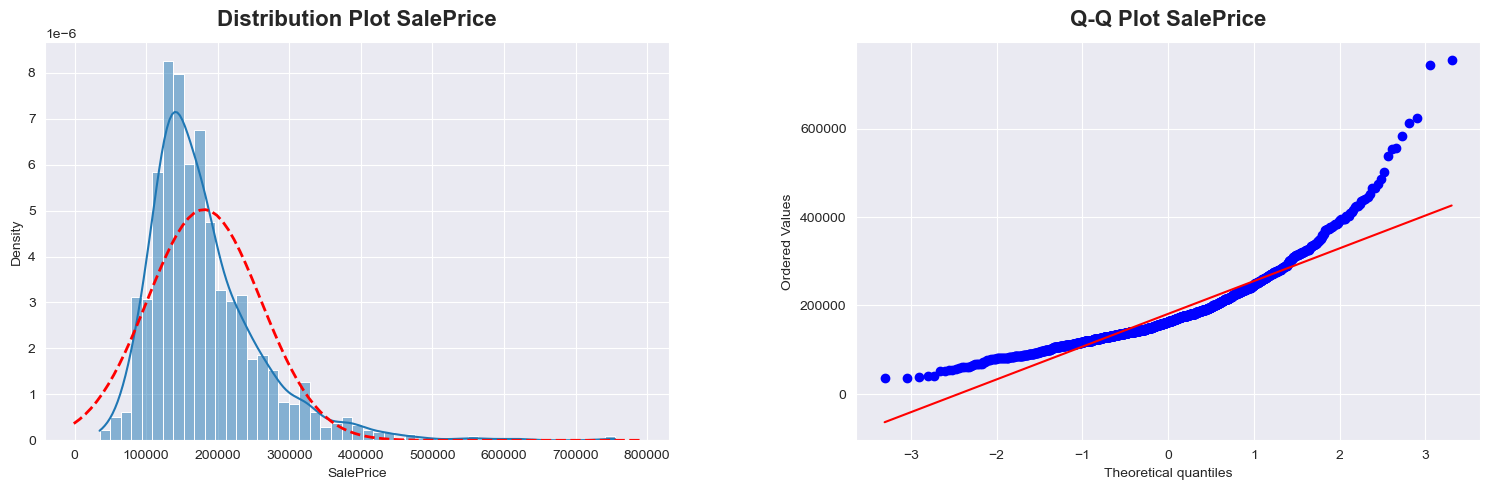

In [100]:
normality_plot(train_df['SalePrice'])


One of the methods to normalize right-skewed data is using log transformation because big values will be pulled to the center. However, log(0) is Nan, so I will use log(1+X) to fix skewness instead.

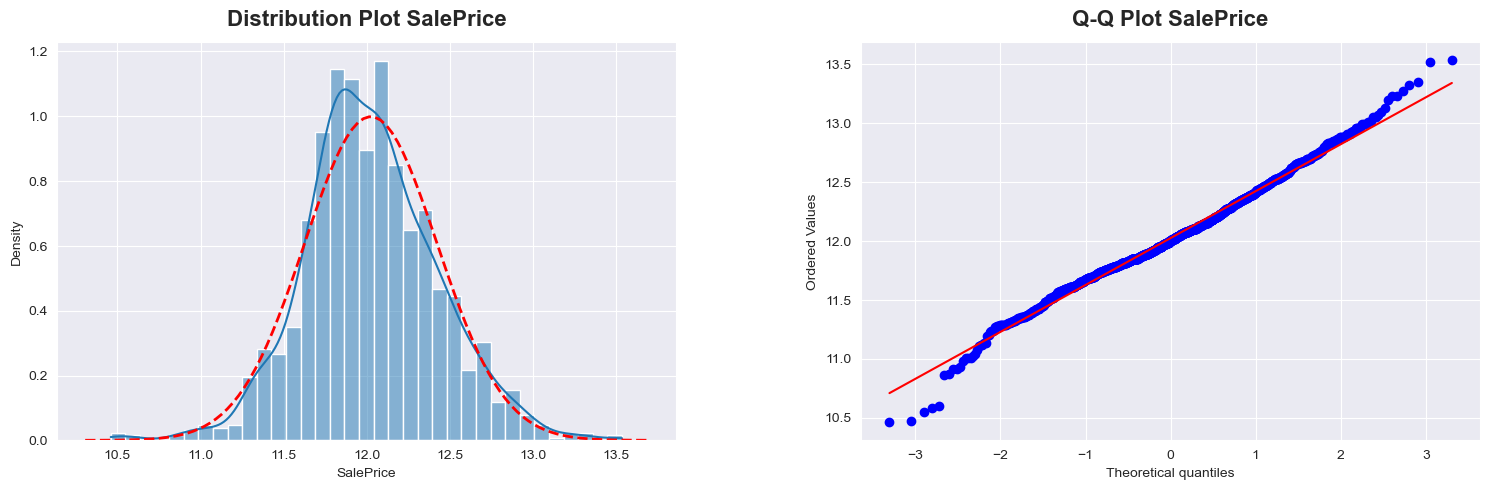

In [101]:
log_saleprice = np.log1p(train_df['SalePrice'])
normality_plot(log_saleprice)


And this is `SalePrice` after log transformation. The sknewness has been fixed.

In the next step, I will examine skewness in the rest of numerical features and use transformation to fix them.

__Fixing skewness in other numerical variables__

If skewness is less than -1 or greater than 1, the distribution is __highly skewed__.

If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is __moderately skewed__.

If skewness is between -0.5 and 0.5, the distribution is __approximately symmetric__.

Below are skewed features in the train data.

In [102]:
skewness_train = train_df[numeric_features].skew().sort_values(ascending=False)
(skewness_train[abs(skewness_train) > 1.5])

MasVnrArea     2.687557
LivAreaQual    1.879622
TotalSF        1.680226
BsmtFinSF1     1.676989
dtype: float64

Let's check normality of __LivAreaQual__:

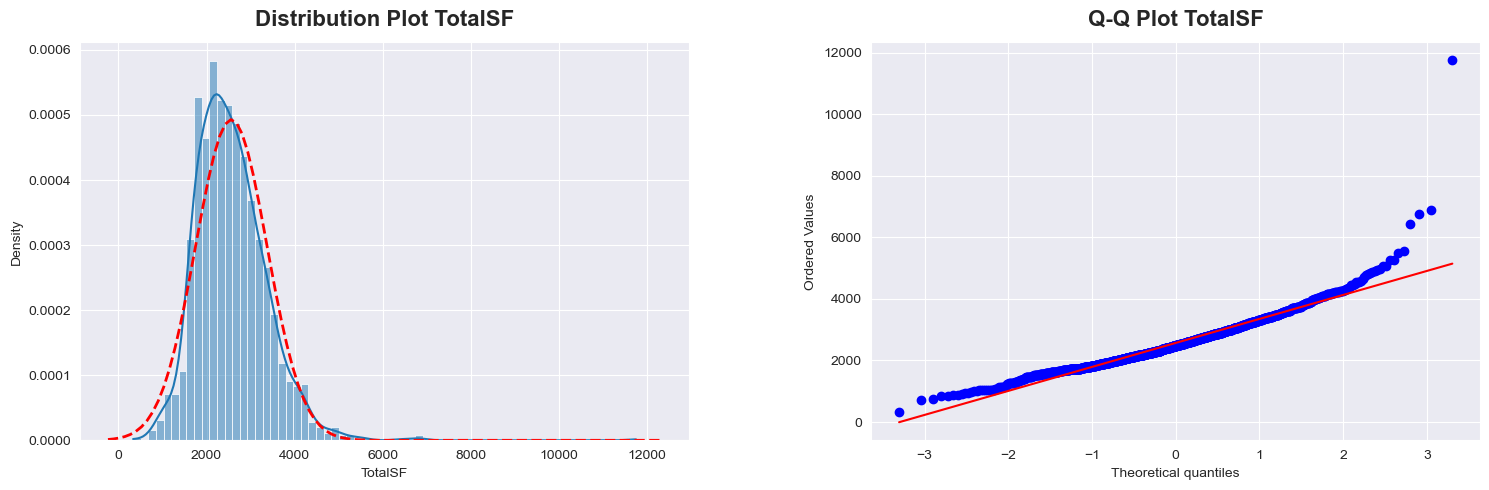

In [103]:
normality_plot(train_df['TotalSF'])


In [104]:

# Identify skewed columns
skewness = train_df[numeric_features].skew().sort_values(ascending=False)
skewed_cols = list(skewness[abs(skewness) > 1.5].index)

# Apply log1p transformation safely
for col in skewed_cols:
    if (train_df[col] >= 0).all() & (test_df[col] >= 0).all():  # only transform non-negative features
        train_df['Log_'+col] = np.log1p(train_df[col])
        test_df['Log_'+col] = np.log1p(test_df[col])
    else:
        print(f"Skipped {col}: contains negative values")



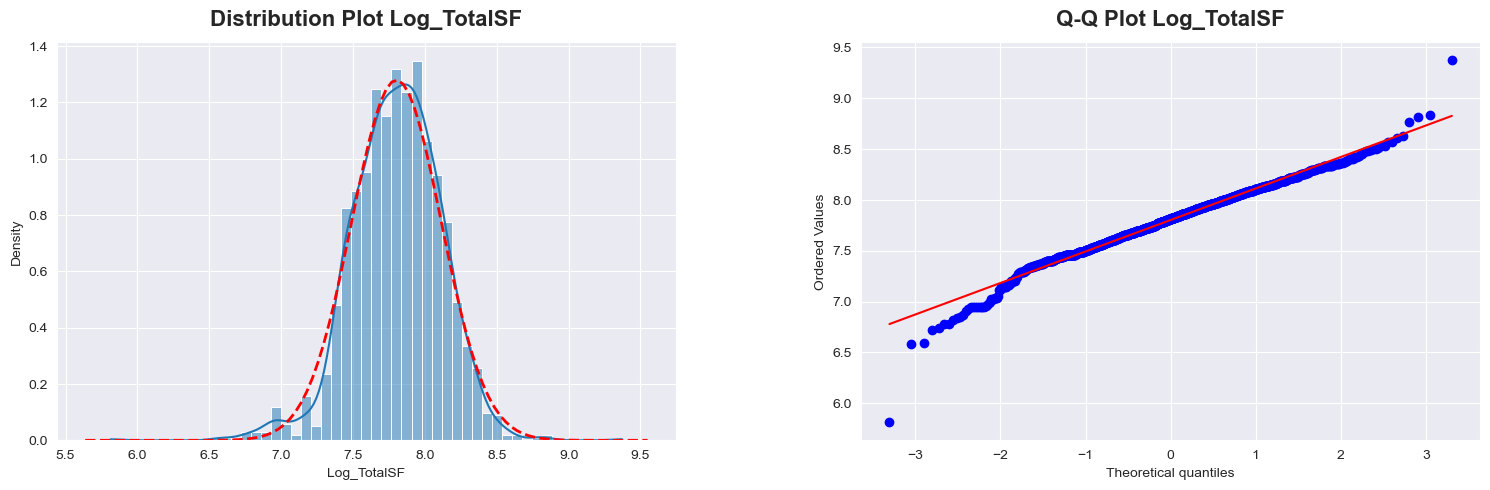

In [106]:
# Plot : Post transformation of LivAreaQual
normality_plot(train_df['Log_TotalSF'])


In [117]:
# Add this to numeric features as well
log_columns = train_df.columns[train_df.columns.str.contains('log', case=False)].tolist()

# check its relation with saleprice
log_scores = compute_f_scores_with_eta(train_df[log_columns], train_df['SalePrice'])
# select features whose eta_square > 0.20
selected_log_col = log_scores[log_scores['Eta_Squared'] > 0.20]['Feature'].tolist()

# add this in numeric features
numeric_features = numeric_features + selected_log_col

In [118]:
# Combine all final features for modeling
final_features = numeric_features + ordinal_features + categorical_features + boolean_features + year_features

y = train_df['SalePrice']
# Log Transformation of target features
y_log = np.log1p(train_df['SalePrice'])

In [119]:
display(train_df[final_features].head())

,LivAreaQual,TotalSF,NeighborhoodMedianPrice,HouseAge,QualCond,RemodeledAge,MasVnrArea,TotalPorchSF,BsmtFinSF1,Log_LivAreaQual,Log_TotalSF,ExterQual,KitchenQual,BsmtQual,GarageFinish,OverallQual,GarageCars,Fireplaces,TotalBath,Neighborhood,HasFireplace,HasGarage,HasPorch,CentralAir,GarageYrBlt
0,11970,2566,197200.0,5,35,5,196.0,61,706,9.390242,7.850493,4,4,4,2,7,2,0,3.5,CollgCr,False,True,True,True,2003
1,7572,2524,218000.0,31,48,31,0.0,298,978,8.932345,7.833996,3,3,4,2,6,2,1,2.5,Veenker,True,True,False,True,1976
2,12502,2706,197200.0,7,35,6,162.0,42,486,9.433724,7.903596,4,4,4,2,7,2,1,3.5,CollgCr,True,True,True,True,2001
3,12019,2473,200624.0,91,35,36,0.0,307,216,9.394327,7.813592,3,4,3,1,7,3,1,2.0,Crawfor,True,True,True,True,1998
4,17584,3343,301500.0,8,40,8,350.0,276,655,9.774802,8.114923,4,4,4,2,8,3,1,3.5,NoRidge,True,True,True,True,2000


In [120]:
display(test_df[final_features].head())

,LivAreaQual,TotalSF,NeighborhoodMedianPrice,HouseAge,QualCond,RemodeledAge,MasVnrArea,TotalPorchSF,BsmtFinSF1,Log_LivAreaQual,Log_TotalSF,ExterQual,KitchenQual,BsmtQual,GarageFinish,OverallQual,GarageCars,Fireplaces,TotalBath,Neighborhood,HasFireplace,HasGarage,HasPorch,CentralAir,GarageYrBlt
0,4480,1778,140000.0,49,30,49,0.0,260,468,8.407602,7.483807,3,3,3,1,5,1,0,1.0,NAmes,False,True,False,True,1961
1,7974,2658,140000.0,52,36,52,108.0,429,923,8.984067,7.885705,3,4,3,1,6,1,0,1.5,NAmes,False,True,True,True,1958
2,8145,2557,181000.0,13,25,12,0.0,246,791,9.005282,7.846981,3,3,4,3,5,2,1,2.5,Gilbert,True,True,True,True,1997
3,9624,2530,181000.0,12,36,12,20.0,396,602,9.172119,7.836370,3,4,3,3,6,2,1,2.5,Gilbert,True,True,True,True,1998
4,10240,2560,278000.0,18,40,18,0.0,226,263,9.234155,7.848153,4,4,4,2,8,2,0,2.0,StoneBr,False,True,True,True,1992


In [121]:
print(train_df[final_features].shape), print(test_df[final_features].shape)

(1459, 25)
(1457, 25)


(None, None)

## __3. Final Datasets for Modeling__

In [122]:
# Prepare datasets for modeling
X_train = train_df[final_features]
y_train = train_df['SalePrice']
X_test = test_df[final_features]

# Check for any remaining missing values
print("Any missing values in X_train :", X_train.isnull().sum().sum())
print("Any missing values in X_test :", X_test.isnull().sum().sum())


Any missing values in X_train : 0
Any missing values in X_test : 0


In [123]:
X_train.shape, y_train.shape, X_test.shape

((1459, 25), (1459,), (1457, 25))

In [124]:
## Save the processed data for modeling in next notebook
# Create a dictionary to store the processed datasets
processed_data = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'test_id': test_id,
    'numeric_features': numeric_features,
    'ordinal_features': ordinal_features,
    'categorical_features': categorical_features,
    'boolean_features': boolean_features,
    'year_features': year_features
}

print("Saving the following for modeling...")
print(f"- X_train Shape: {X_train.shape}")
print(f"- y_train Shape: {y_train.shape}")
print(f"- X_test Shape: {X_test.shape}")
print(f"- test_id Shape: {test_id.shape}")
print(f"- Numeric Features: {len(numeric_features)}")
print(f"- Ordinal Features: {len(ordinal_features)}")
print(f"- Categorical Features: {len(categorical_features)}")
print(f"- Boolean Features: {len(boolean_features)}")
print(f"- Year Features: {len(year_features)}")



Saving the following for modeling...
- X_train Shape: (1459, 25)
- y_train Shape: (1459,)
- X_test Shape: (1457, 25)
- test_id Shape: (1457,)
- Numeric Features: 11
- Ordinal Features: 8
- Categorical Features: 1
- Boolean Features: 4
- Year Features: 1


In [125]:
#Step1 : Create a directory/folder for models if it doesn't exist
model_dir = parent_path.joinpath("models")
model_dir.mkdir(parents=True, exist_ok=True)

In [126]:
# Step 2: Save the dictionary
# Save the processed data as a pickle file
import pickle

# Define file path inside models directory
file_path = model_dir.joinpath("processed.pkl")

# Save dictionary as a pickle file
with open(file_path, 'wb') as f:
    pickle.dump(processed_data, f)



In [127]:
# Step 3: Load it back to verify
with open(file_path, 'rb') as f:
    loaded_data = pickle.load(f)

In [128]:
print("Processed data saved and loaded successfully for modeling!")
print("="*40, "COMPLETED", "="*40)

Processed data saved and loaded successfully for modeling!
======================================== COMPLETED ========================================
